<h1>Exploratory Data Analysis<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Analysis-checklist" data-toc-modified-id="Analysis-checklist-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Analysis checklist</a></span></li><li><span><a href="#Imports" data-toc-modified-id="Imports-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Imports</a></span><ul class="toc-item"><li><span><a href="#Libraries" data-toc-modified-id="Libraries-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Libraries</a></span></li><li><span><a href="#Data" data-toc-modified-id="Data-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Data</a></span></li></ul></li><li><span><a href="#Analyse-de-Forme-:" data-toc-modified-id="Analyse-de-Forme-:-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Analyse de Forme :</a></span></li><li><span><a href="#Analyse-de-Fond" data-toc-modified-id="Analyse-de-Fond-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Analyse de Fond</a></span><ul class="toc-item"><li><span><a href="#Target" data-toc-modified-id="Target-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Target</a></span></li><li><span><a href="#Features" data-toc-modified-id="Features-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Features</a></span><ul class="toc-item"><li><span><a href="#Quantitatives" data-toc-modified-id="Quantitatives-4.2.1"><span class="toc-item-num">4.2.1&nbsp;&nbsp;</span>Quantitatives</a></span></li><li><span><a href="#Qualitatives" data-toc-modified-id="Qualitatives-4.2.2"><span class="toc-item-num">4.2.2&nbsp;&nbsp;</span>Qualitatives</a></span></li></ul></li></ul></li></ul></div>

## Analysis checklist

<u>**Analyse de Forme**</u> :
- **variable target** : median_house_value
- **lignes et colonnes** : 16512 rows × 10 columns
- **types de variables** : qualitatives : 1, quantitatives : 9
- **valeurs manquantes** : 176 (soit 1%) dans total_bedrooms

<u>**Analyse de Fond**</u> :
- **Visualisation de la target** :  
    - Variable continue
    - Min = 14,999 et Max = 500,001 
    - Médiane à 179,300 et un pic à 500,001 (outlier?)
- **Remarques sur les variables** :  
    - People : population - households : Distribution asymétriques très similaires (skewed data)
    - Appartements : total rooms/bedrooms : Distribution asymétriques très similaires (skewed data)
    - Localisation : Long-Latt sont très corrélés avec 2 pics qui semblent être 2 grandes villes / Ocean_proximity est une variable avec 5 catégories
    - Argent : Income revenue est corrélé avec median house value
    - "Inland" et "<1h Ocean" semblent se distinguer en distribution avec un pic pour toutes les catégories à 500,001
    - Grâce à un graph long-latt on peut mettre en évidence les zones selon leur prix

<u>**Idées/Hypothèses**</u> :  
- "Assembler" les 2 variables de localisation car représente une zone géographique et sont fortements corrélées ce qui permettrait de créer des "clusters" ou autre chose??
- Séparer les 5 catégories d'ocean_proximity pour les visualiser et analyser - Créer 3 catégories au lieu de 5
- Nous avons 3 ensembles de données : Localisation / People / Caractéristiques maisons / Argent --> Que puis-je en tirer?

## Imports

### Libraries

In [3]:
import warnings
warnings.filterwarnings('ignore')

# Data manip
import pandas as pd
#import pandas_profiling
import numpy as np

# Dataviz
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Data

In [4]:
data = pd.read_csv("data/data_init.txt")
df = data.copy()
df=df.drop(["Unnamed: 0"], axis=1, errors='ignore')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-119.84,36.77,6.0,1853.0,473.0,1397.0,417.0,1.4817,72000.0,INLAND
1,-117.80,33.68,8.0,2032.0,349.0,862.0,340.0,6.9133,274100.0,<1H OCEAN
2,-120.19,36.60,25.0,875.0,214.0,931.0,214.0,1.5536,58300.0,INLAND
3,-118.32,34.10,31.0,622.0,229.0,597.0,227.0,1.5284,200000.0,<1H OCEAN
4,-121.23,37.79,21.0,1922.0,373.0,1130.0,372.0,4.0815,117900.0,INLAND


## Analyse de Forme :

In [5]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-119.84,36.77,6.0,1853.0,473.0,1397.0,417.0,1.4817,72000.0,INLAND
1,-117.80,33.68,8.0,2032.0,349.0,862.0,340.0,6.9133,274100.0,<1H OCEAN
2,-120.19,36.60,25.0,875.0,214.0,931.0,214.0,1.5536,58300.0,INLAND
3,-118.32,34.10,31.0,622.0,229.0,597.0,227.0,1.5284,200000.0,<1H OCEAN
4,-121.23,37.79,21.0,1922.0,373.0,1130.0,372.0,4.0815,117900.0,INLAND
...,...,...,...,...,...,...,...,...,...,...
16507,-121.90,39.59,20.0,1465.0,278.0,745.0,250.0,3.0625,93800.0,INLAND
16508,-122.25,38.11,49.0,2365.0,504.0,1131.0,458.0,2.6133,103100.0,NEAR BAY
16509,-121.22,38.92,19.0,2531.0,461.0,1206.0,429.0,4.4958,192600.0,INLAND
16510,-118.14,34.16,39.0,2776.0,840.0,2546.0,773.0,2.5750,153500.0,<1H OCEAN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16336 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.3+ MB


In [7]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        176
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## Analyse de Fond

### Target

In [8]:
df[["median_house_value"]].describe()

,median_house_value
count,16512.000000
mean,206509.251453
std,115225.957661
min,14999.000000
25%,119400.000000
50%,179300.000000
75%,264500.000000
max,500001.000000


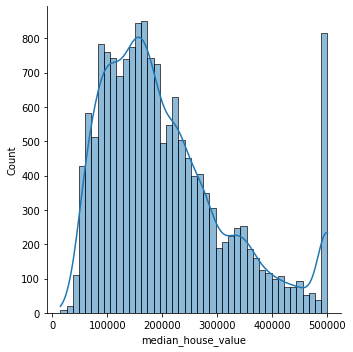

In [9]:
sns.displot(df["median_house_value"], kde=True)

### Features

#### Quantitatives

<Figure size 432x288 with 0 Axes>

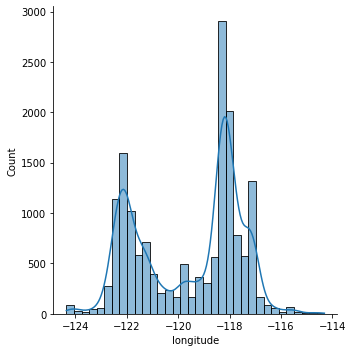

<Figure size 432x288 with 0 Axes>

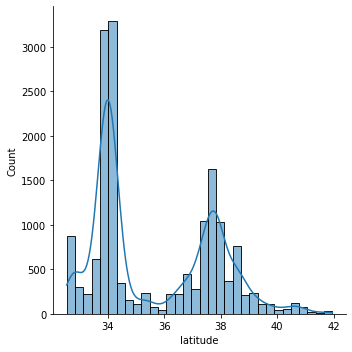

<Figure size 432x288 with 0 Axes>

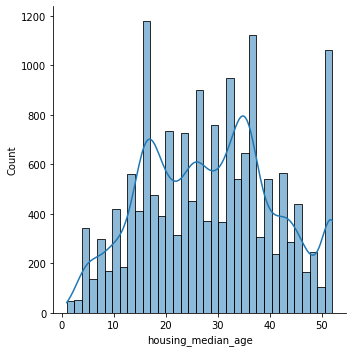

<Figure size 432x288 with 0 Axes>

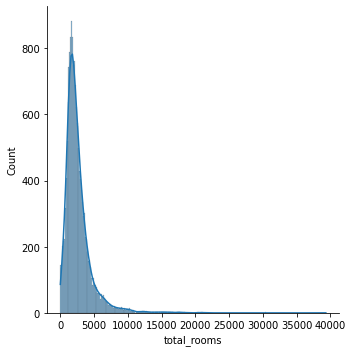

<Figure size 432x288 with 0 Axes>

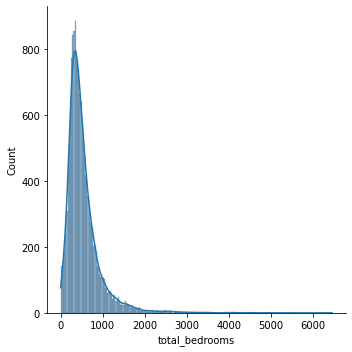

<Figure size 432x288 with 0 Axes>

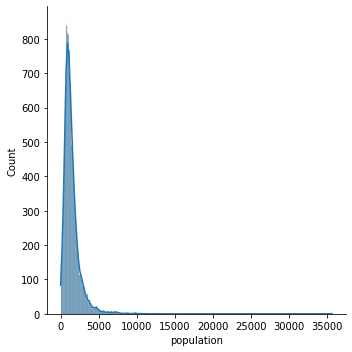

<Figure size 432x288 with 0 Axes>

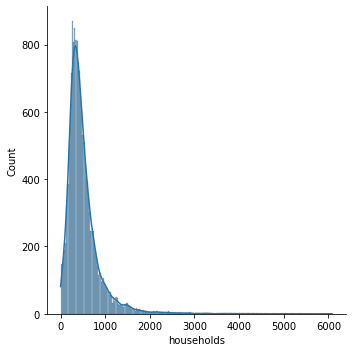

<Figure size 432x288 with 0 Axes>

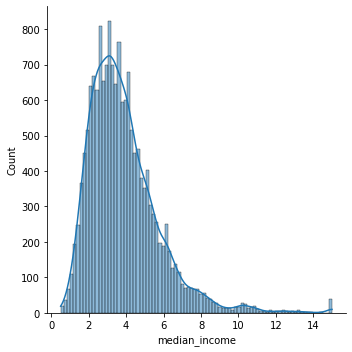

<Figure size 432x288 with 0 Axes>

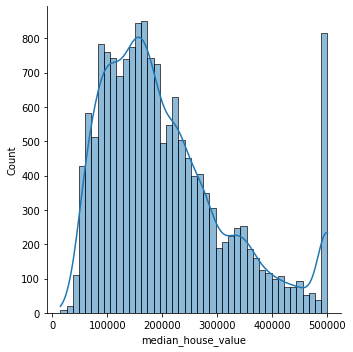

In [10]:
for col in df.select_dtypes("float"):
    plt.figure()
    sns.displot(df[col], kde=True)

#### Qualitatives

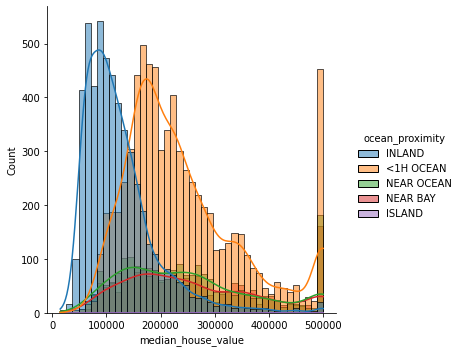

In [11]:
sns.displot(data=df, x=df["median_house_value"], hue="ocean_proximity", kde=True)

Création de 5 sous ensembles d'ocean_proximity pour les visualiser individuellement

In [12]:
df_inland = df[(df['ocean_proximity'] == 'INLAND')]
df_1h_ocean = df[(df['ocean_proximity'] == '<1H OCEAN')]
df_nearo = df[(df['ocean_proximity'] == 'NEAR OCEAN')]
df_nearb = df[(df['ocean_proximity'] == 'NEAR BAY')]
df_island = df[(df['ocean_proximity'] == 'ISLAND')]

<Figure size 432x288 with 0 Axes>

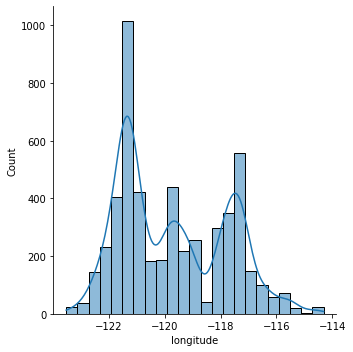

<Figure size 432x288 with 0 Axes>

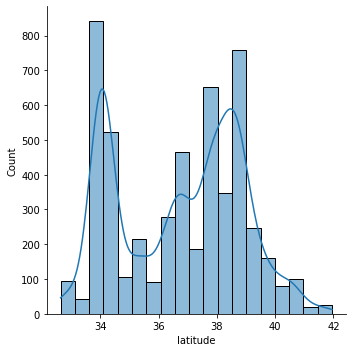

<Figure size 432x288 with 0 Axes>

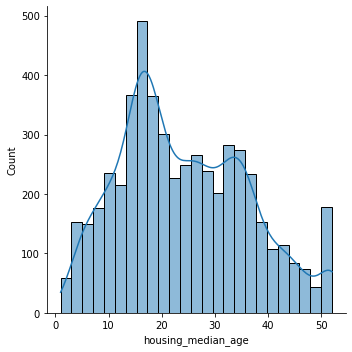

<Figure size 432x288 with 0 Axes>

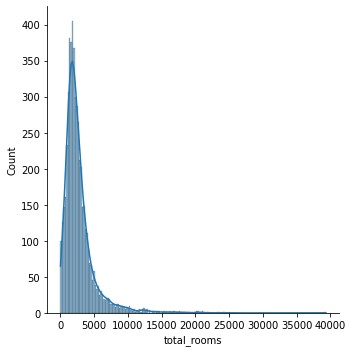

<Figure size 432x288 with 0 Axes>

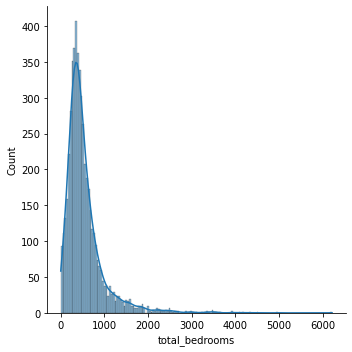

<Figure size 432x288 with 0 Axes>

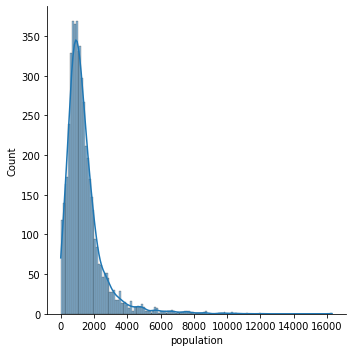

<Figure size 432x288 with 0 Axes>

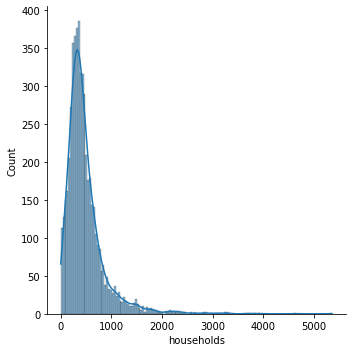

<Figure size 432x288 with 0 Axes>

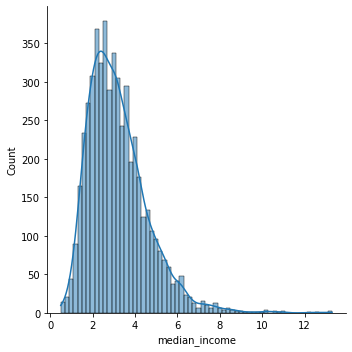

<Figure size 432x288 with 0 Axes>

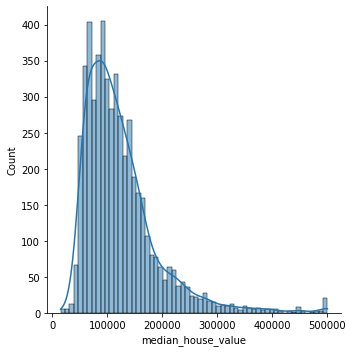

In [13]:
for col in df_inland.select_dtypes("float"):
    plt.figure()
    sns.displot(df_inland[col], kde=True)

<AxesSubplot:>

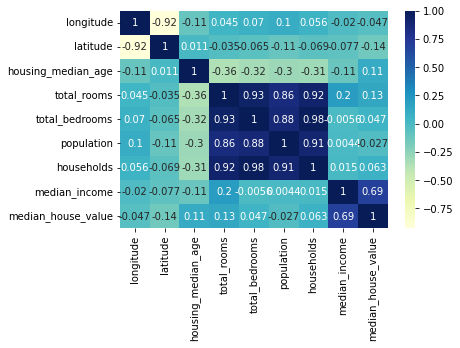

In [14]:
corr = df.corr()
sns.heatmap(corr,
            xticklabels=corr.columns,
            yticklabels=corr.columns,
            cmap="YlGnBu", annot=True)

In [15]:
# Unstack correlation matrix
corr_df = corr.unstack().reset_index()
corr_df

# rename columns
corr_df.columns = ['feature_1', 'Target', 'correlation']

# # sort by correlation
corr_df.sort_values(by="correlation", ascending=False, inplace=True)

# Show only median_house_value correlation
corr_df = corr_df[corr_df['feature_1'] == 'median_house_value']
corr_df

,feature_1,Target,correlation
80,median_house_value,median_house_value,1.000000
79,median_house_value,median_income,0.689659
75,median_house_value,total_rooms,0.133218
74,median_house_value,housing_median_age,0.108626
78,median_house_value,households,0.063245
76,median_house_value,total_bedrooms,0.047478
77,median_house_value,population,-0.027441
72,median_house_value,longitude,-0.046754
73,median_house_value,latitude,-0.143970


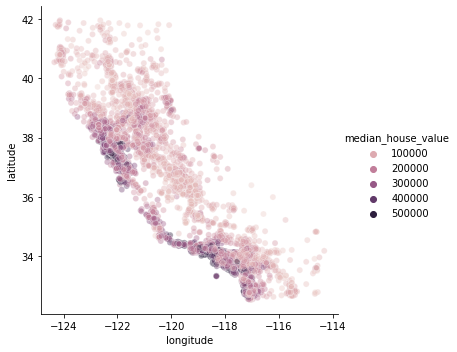

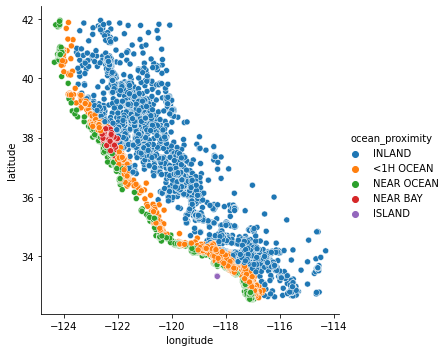

In [16]:
sns.relplot(x="longitude", y="latitude", data=df, hue="median_house_value", alpha=0.4)
sns.relplot(x="longitude", y="latitude", data=df, hue="ocean_proximity")

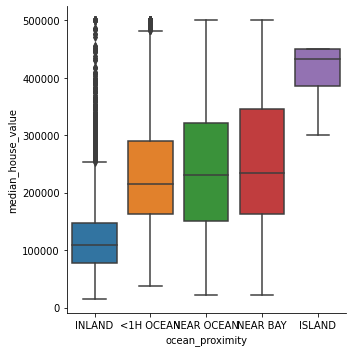

In [17]:
sns.catplot(x="ocean_proximity", y="median_house_value", kind="box", data=df)